# Tarea 1 - Análisis de Rendimiento y Riesgo de Activos Financieros

**Materia:** Portafolios de Inversión  
**Activos analizados:** PRGO, PLTR y BRK-B  
**Periodo de análisis:** 01/01/2018 - 30/08/2026

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
tickers = ['PRGO', 'PLTR', 'BRK-B']

## 1. Investigación de las emisoras

### PRGO - Perrigo Company plc

#### ¿A qué se dedica?

#### Sector económico según GICS

#### Principales competidores

#### Estado de Resultados

#### Balance General

#### Flujo de Efectivo


### PLTR - Palantir Technologies Inc.

#### ¿A qué se dedica?

#### Sector económico según GICS

#### Principales competidores

#### Estado de Resultados

#### Balance General

#### Flujo de Efectivo


### BRK-B - Berkshire Hathaway Inc.

#### ¿A qué se dedica?

#### Sector económico según GICS

#### Principales competidores

#### Estado de Resultados

#### Balance General

#### Flujo de Efectivo


## 2. Precios de cierre ajustado y rendimientos diarios

### Descarga de precios

In [17]:
prices = yf.download(tickers, start='2018-01-01', end='2026-08-31')["Close"]

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_19232/3322403050.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start='2018-01-01', end='2026-08-31')["Close"]
[*********************100%***********************]  3 of 3 completed


In [18]:
prices

Ticker,BRK-B,PLTR,PRGO
Date,,,
2018-01-02,197.220001,NaN,68.452713
2018-01-03,199.789993,NaN,68.261902
2018-01-04,200.690002,NaN,69.513588
2018-01-05,201.419998,NaN,69.589897
2018-01-08,202.740005,NaN,68.788498
...,...,...,...
2026-08-24,504.320007,175.889999,13.982018
2026-08-25,504.320007,172.729996,14.187779
2026-08-26,504.910004,177.500000,14.462130


In [19]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2176 entries, 2018-01-02 to 2026-08-28
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BRK-B   2176 non-null   float64
 1   PLTR    1485 non-null   float64
 2   PRGO    2176 non-null   float64
dtypes: float64(3)
memory usage: 68.0 KB


In [20]:
prices.describe()


Ticker,BRK-B,PLTR,PRGO
count,2176.000000,1485.000000,2176.000000
mean,319.997537,53.879481,33.083441
std,110.649983,58.027851,12.503698
min,162.130005,6.000000,8.833573
25%,213.167500,14.150000,25.244928
50%,293.589996,23.730000,32.200470
75%,416.004997,87.449997,38.555378
max,539.799988,207.179993,72.619843


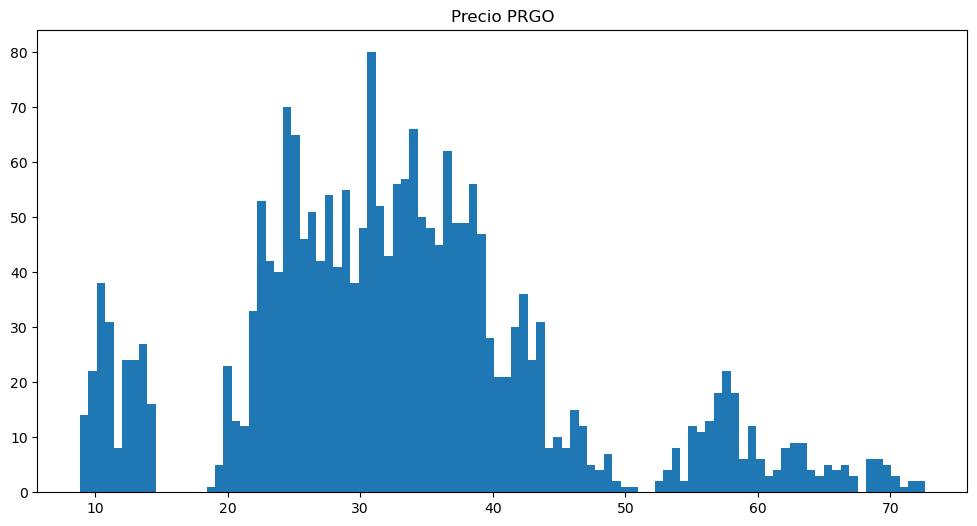

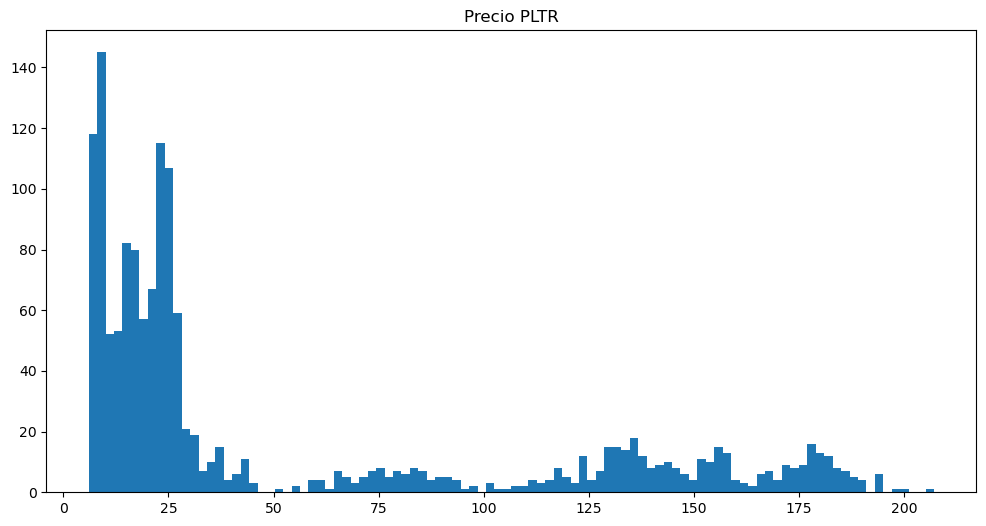

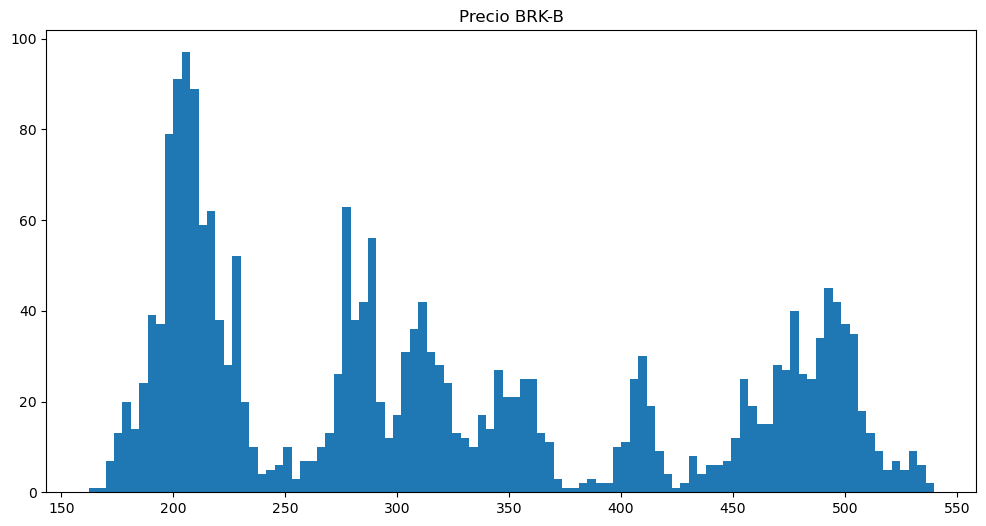

In [21]:
for i in tickers:
    plt.figure(figsize=(12, 6))
    plt.hist(prices[i], bins=100)
    plt.title(f'Precio {i}')
    plt.show(i)

### Cálculo de rendimientos diarios

In [22]:
daily_rets=prices/prices.shift()-1

In [23]:
daily_rets

Ticker,BRK-B,PLTR,PRGO
Date,,,
2018-01-02,NaN,NaN,NaN
2018-01-03,0.013031,NaN,-0.002787
2018-01-04,0.004505,NaN,0.018337
2018-01-05,0.003637,NaN,0.001098
2018-01-08,0.006554,NaN,-0.011516
...,...,...,...
2026-08-24,0.017143,-0.022508,0.001404
2026-08-25,0.000000,-0.017966,0.014716
2026-08-26,0.001170,0.027615,0.019337


### Distribución de rendimientos diarios

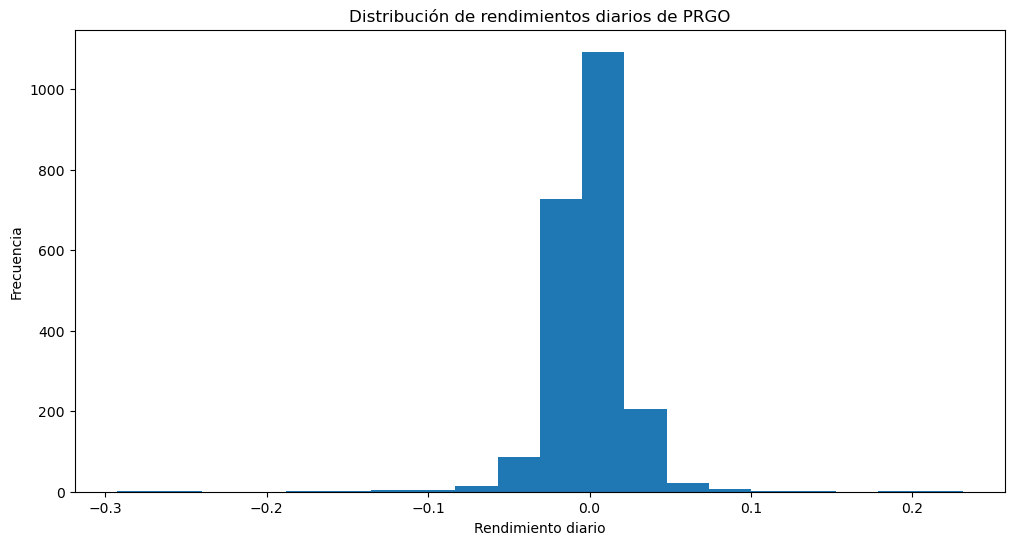

In [26]:
plt.figure(figsize=(12, 6))
plt.hist(daily_rets['PRGO'].dropna(), bins=20)
plt.title('Distribución de rendimientos diarios de PRGO')
plt.xlabel('Rendimiento diario')
plt.ylabel('Frecuencia')
plt.show()

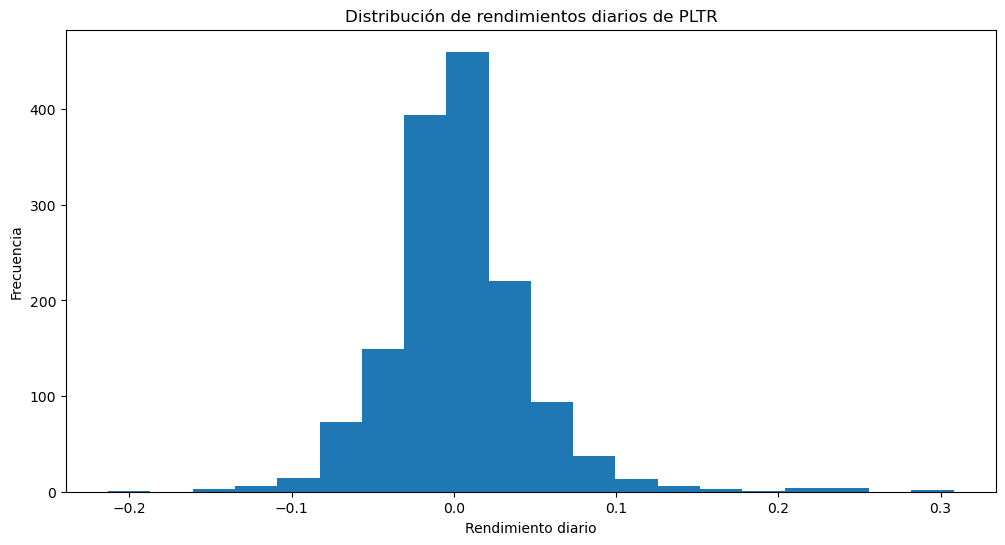

In [27]:
plt.figure(figsize=(12, 6))
plt.hist(daily_rets['PLTR'].dropna(), bins=20)
plt.title('Distribución de rendimientos diarios de PLTR')
plt.xlabel('Rendimiento diario')
plt.ylabel('Frecuencia')
plt.show()

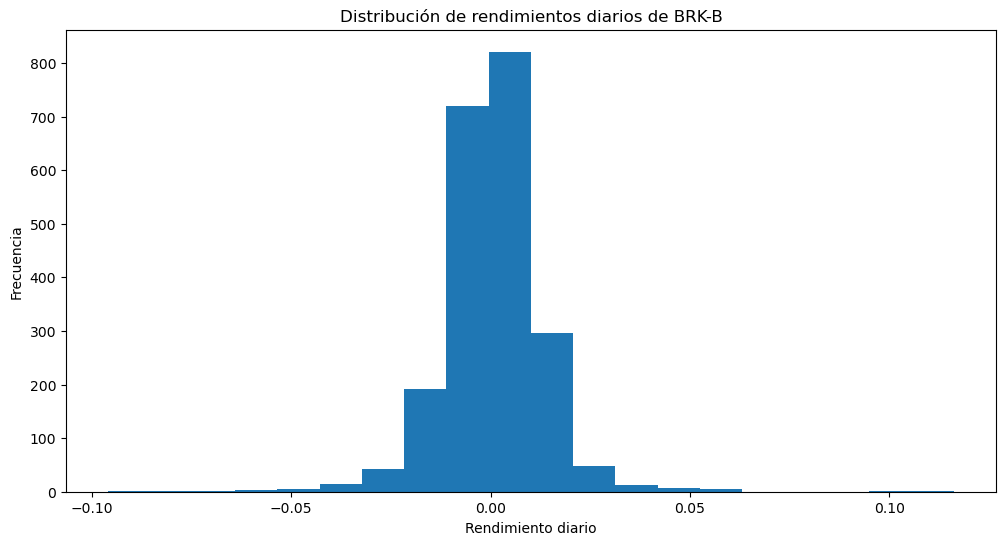

In [28]:
plt.figure(figsize=(12, 6))
plt.hist(daily_rets['BRK-B'].dropna(), bins=20)
plt.title('Distribución de rendimientos diarios de BRK-B')
plt.xlabel('Rendimiento diario')
plt.ylabel('Frecuencia')
plt.show()

## 3. Rendimiento promedio anual

In [29]:
daily_mean=daily_rets.mean()
daily_mean*100


Ticker
BRK-B    0.051495
PLTR     0.295872
PRGO    -0.040559
dtype: float64

In [30]:
annual_mean=daily_mean*252
annual_mean*100

Ticker
BRK-B    12.976825
PLTR     74.559765
PRGO    -10.220918
dtype: float64

### Interpretación

En el periodo analizado el activo que presenta un mayor rendimiento promedio anual con un 74.55% es PLTR, BRK-B con un 12.97% y PRGO con rendimiento anual promedio negativo de -10.22% lo que nos dice que en en promedio su comportamiento fue desfavorable para un inversionista

## 4. Riesgo anual

### Varianza anual

In [34]:
daily_variance=daily_rets.var()
annual_variance=daily_variance*252
annual_variance*100

Ticker
BRK-B     4.158176
PLTR     49.381539
PRGO     15.158989
dtype: float64

Las unidades de la varianza no se pueden interpretar directamente   
por lo que se recomienda calcular la desviación estándar, que es la raíz cuadrada de la varianza.   
La desviación estándar nos da una idea de la dispersión de los datos y se puede interpretar en las mismas unidades que los datos originales.

### Volatilidad anual

In [35]:
daily_volatility=daily_rets.std()
daily_volatility*100

Ticker
BRK-B    1.284550
PLTR     4.426720
PRGO     2.452646
dtype: float64

In [36]:
volatility_annual=daily_volatility*np.sqrt(252)
volatility_annual

Ticker
BRK-B    0.203916
PLTR     0.702720
PRGO     0.389345
dtype: float64

### Coeficiente de Variación

In [37]:
CV=volatility_annual/annual_mean
CV

Ticker
BRK-B    1.571386
PLTR     0.942492
PRGO    -3.809301
dtype: float64

### Comparación de los activos

### ¿Qué activo es mejor?

## 5. Asimetría

### Interpretación

### Conclusión final